In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find the file {file_path}")

Data loaded successfully!


In [ ]:
#1. Basic Information
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        52

In [ ]:
# 2. Data Cleaning (Basic)
df.dropna(subset=['Selling_Price', 'Year', 'Fuel_Type', 'Transmission'], inplace=True)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


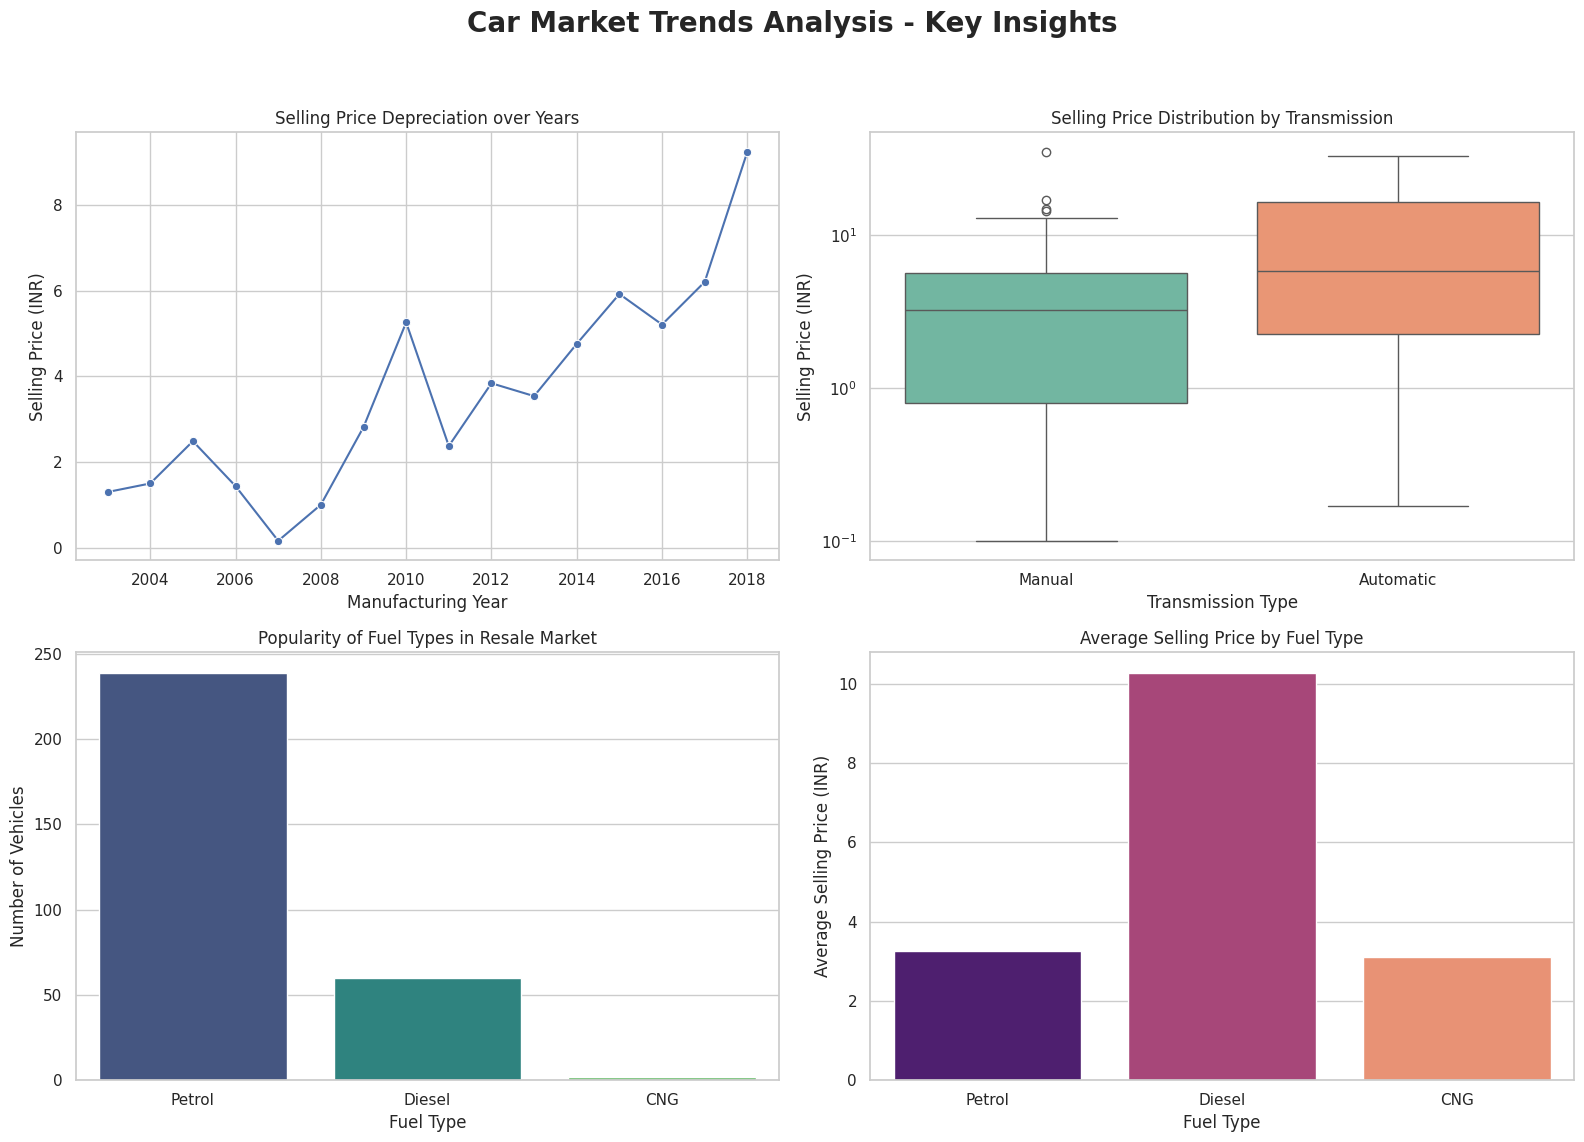


--- Key Findings---
Average Price (Automatic): ₹9.42
Average Price (Manual): ₹3.93


In [22]:
sns.set_theme(style="whitegrid")
# 3. Exploratory Data Analysis & Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Car Market Trends Analysis - Key Insights', fontsize=20, fontweight='bold')

# Visualization A: Impact of Manufacturing Year on Selling Price
sns.lineplot(ax=axes[0, 0], data=df, x='Year', y='Selling_Price', errorbar=None, marker='o', color='b')
axes[0, 0].set_title('Selling Price Depreciation over Years')
axes[0, 0].set_xlabel('Manufacturing Year')
axes[0, 0].set_ylabel('Selling Price (INR)')

# Visualization B: Price Comparison by Transmission Type
sns.boxplot(ax=axes[0, 1], data=df, x='Transmission', y='Selling_Price', palette='Set2', hue='Transmission', legend=False)
axes[0, 1].set_title('Selling Price Distribution by Transmission')
axes[0, 1].set_xlabel('Transmission Type')
axes[0, 1].set_ylabel('Selling Price (INR)')
axes[0, 1].set_yscale('log') # Using log scale if price outliers squash the boxplot

# Visualization C: Market Share of Different Fuel Types
fuel_counts = df['Fuel_Type'].value_counts()
sns.barplot(ax=axes[1, 0], x=fuel_counts.index, y=fuel_counts.values, palette='viridis', hue=fuel_counts.index, legend=False)
axes[1, 0].set_title('Popularity of Fuel Types in Resale Market')
axes[1, 0].set_xlabel('Fuel Type')
axes[1, 0].set_ylabel('Number of Vehicles')

# Visualization D: Average Selling Price by Fuel Type
sns.barplot(ax=axes[1, 1], data=df, x='Fuel_Type', y='Selling_Price', errorbar=None, palette='magma', hue='Fuel_Type', legend=False)
axes[1, 1].set_title('Average Selling Price by Fuel Type')
axes[1, 1].set_xlabel('Fuel Type')
axes[1, 1].set_ylabel('Average Selling Price (INR)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Extracting Key Metrics
avg_price_auto = df[df['Transmission'] == 'Automatic']['Selling_Price'].mean()
avg_price_manual = df[df['Transmission'] == 'Manual']['Selling_Price'].mean()

print("\n--- Key Findings---")
print(f"Average Price (Automatic): ₹{avg_price_auto:,.2f}")
print(f"Average Price (Manual): ₹{avg_price_manual:,.2f}")